In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/urayushmishra/galeroiiii/GaleROIIII.hdr
/kaggle/input/datasets/urayushmishra/galeroiiii/GaleROIIII
/kaggle/input/datasets/urayushmishra/gale-crater/min_set3
/kaggle/input/datasets/urayushmishra/gale-crater/frt0000a425_07_if166j_mtr3.img
/kaggle/input/datasets/urayushmishra/gale-crater/min_set3.hdr
/kaggle/input/datasets/urayushmishra/gale-crater/frt0000a425_07_if166j_mtr3.lbl
/kaggle/input/datasets/urayushmishra/gale-crater/frt0000a425_07_if166j_mtr3.hdr


In [2]:
pip install spectral

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 249.0/249.0 kB 12.5 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter

from spectral import envi
from scipy.ndimage import gaussian_filter1d

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

import seaborn as sns
import joblib

np.random.seed(42)

In [4]:
from spectral import envi

data_dir = Path("/kaggle/input/datasets/urayushmishra/gale-crater")

hdr_file = data_dir / "min_set3.hdr"
data_file = data_dir / "min_set3"

lib = envi.open(str(hdr_file), str(data_file))

spectra = np.asarray(lib.spectra, dtype=np.float32)
names = [str(n).strip() for n in lib.names]

print("Spectra shape:", spectra.shape)
print("First 10 names:")
print(names[:10])

Spectra shape: (91, 420)
First 10 names:
['augite1.spc Augite NMNH120049', 'augite2.spc Augite WS588', 'augite3.spc Augite WS592', 'chlorit1.spc Chlorite HS179.3B', 'chlorit2.spc Chlorite SMR-13.a 104-150', 'chlorit3.spc Chlorite SMR-13.b 60-104u', 'chlorit4.spc Chlorite SMR-13.c 45-60um', 'chlorit5.spc Chlorite SMR-13.d 30-45um', 'chlorit6.spc Chlorite SMR-13.e <30um', 'gypsum1.spc Gypsum HS333.3B']


In [5]:
def get_label(name):
    n = name.lower()

    if any(x in n for x in ["nontronite", "montmorillonite", "saponite", "illite", "chlorite"]):
        return "clay"
    elif "kaolinite" in n:
        return "kaolinite"
    elif any(x in n for x in ["serpentine", "talc"]):
        return "silicate"
    elif any(x in n for x in ["gypsum", "jarosite"]):
        return "sulfate"
    elif "hematite" in n:
        return "oxide"
    elif any(x in n for x in ["carbonate", "dolomite", "magnesite"]):
        return "carbonate"
    elif any(x in n for x in ["opal", "quartz", "silica"]):
        return "silica"
    elif any(x in n for x in ["pyroxene", "augite"]):
        return "pyroxene"
    elif "olivine" in n:
        return "olivine"
    else:
        return "unknown"

y = np.array([get_label(n) for n in names])

mask = y != "unknown"
X = spectra[mask]
y = y[mask]
names = np.array(names)[mask]

print("Kept spectra:", X.shape)
print("Class counts:", Counter(y))

Kept spectra: (91, 420)
Class counts: Counter({np.str_('clay'): 26, np.str_('olivine'): 17, np.str_('oxide'): 12, np.str_('sulfate'): 11, np.str_('kaolinite'): 8, np.str_('silica'): 6, np.str_('silicate'): 6, np.str_('pyroxene'): 4, np.str_('carbonate'): 1})


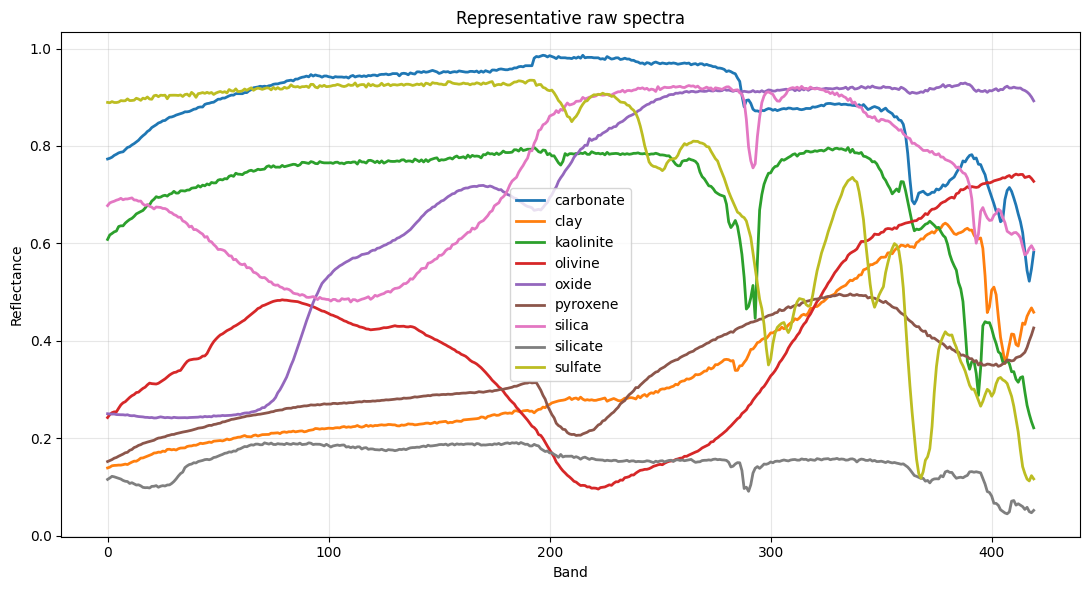

In [6]:
plt.figure(figsize=(11, 6))

for cls in np.unique(y):
    idx = np.where(y == cls)[0][0]
    plt.plot(np.arange(X.shape[1]), X[idx], label=cls, linewidth=2)

plt.xlabel("Band")
plt.ylabel("Reflectance")
plt.title("Representative raw spectra")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [7]:
le = LabelEncoder()
y_enc = le.fit_transform(y)

print("Classes:", list(le.classes_))
print("Encoded counts:", Counter(y_enc))

Classes: [np.str_('carbonate'), np.str_('clay'), np.str_('kaolinite'), np.str_('olivine'), np.str_('oxide'), np.str_('pyroxene'), np.str_('silica'), np.str_('silicate'), np.str_('sulfate')]
Encoded counts: Counter({np.int64(1): 26, np.int64(3): 17, np.int64(4): 12, np.int64(8): 11, np.int64(2): 8, np.int64(6): 6, np.int64(7): 6, np.int64(5): 4, np.int64(0): 1})


In [8]:
from collections import Counter
print(Counter(y))

Counter({np.str_('clay'): 26, np.str_('olivine'): 17, np.str_('oxide'): 12, np.str_('sulfate'): 11, np.str_('kaolinite'): 8, np.str_('silica'): 6, np.str_('silicate'): 6, np.str_('pyroxene'): 4, np.str_('carbonate'): 1})


In [9]:
from collections import Counter
import numpy as np

counts = Counter(y)
keep_classes = [cls for cls, cnt in counts.items() if cnt >= 2]

mask = np.isin(y, keep_classes)
X = X[mask]
y = y[mask]

print("Kept classes:", keep_classes)
print("New counts:", Counter(y))

Kept classes: [np.str_('pyroxene'), np.str_('clay'), np.str_('sulfate'), np.str_('oxide'), np.str_('kaolinite'), np.str_('silica'), np.str_('olivine'), np.str_('silicate')]
New counts: Counter({np.str_('clay'): 26, np.str_('olivine'): 17, np.str_('oxide'): 12, np.str_('sulfate'): 11, np.str_('kaolinite'): 8, np.str_('silica'): 6, np.str_('silicate'): 6, np.str_('pyroxene'): 4})


In [10]:
le = LabelEncoder()
y_enc = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_enc,
    test_size=0.2,
    random_state=42,
    stratify=y_enc
)

In [11]:
def augment_spectrum(spec, rng):
    spec = spec.astype(np.float32)
    n = spec.size
    x = np.linspace(-1.0, 1.0, n, dtype=np.float32)

    scale = rng.uniform(0.95, 1.05)
    slope = 1.0 + rng.uniform(-0.03, 0.03) * x
    curve = 1.0 + rng.uniform(-0.02, 0.02) * (x**2 - 1.0/3.0)

    noise_level = max(1e-6, 0.005 * np.std(spec))
    raw_noise = rng.normal(0.0, noise_level, size=n).astype(np.float32)
    smooth_noise = gaussian_filter1d(raw_noise, sigma=rng.uniform(0.5, 1.5))

    band_jitter = rng.normal(1.0, 0.002, size=n).astype(np.float32)

    aug = spec * scale * slope * curve * band_jitter + smooth_noise
    aug = np.nan_to_num(aug, nan=0.0, posinf=0.0, neginf=0.0)
    aug = np.clip(aug, 0.0, None)
    return aug

In [12]:
rng = np.random.default_rng(42)

N_AUG_PER_SAMPLE = 40

X_aug = []
y_aug = []

for i, spec in enumerate(X_train):
    # original sample
    X_aug.append(spec)
    y_aug.append(y_train[i])

    # augmented samples
    for _ in range(N_AUG_PER_SAMPLE):
        X_aug.append(augment_spectrum(spec, rng))
        y_aug.append(y_train[i])

X_aug = np.vstack(X_aug)
y_aug = np.array(y_aug)

print("Augmented shape:", X_aug.shape)
print("Augmented labels shape:", y_aug.shape)

Augmented shape: (2952, 420)
Augmented labels shape: (2952,)


In [13]:
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(random_state=42)),
    ("svm", SVC(class_weight="balanced"))
])

param_grid = {
    "pca__n_components": [10, 15, 20, 30],
    "svm__C": [0.1, 1, 10, 100],
    "svm__gamma": ["scale", 0.01, 0.1]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    pipe,
    param_grid=param_grid,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1,
    verbose=2
)

grid.fit(X_aug, y_aug)

print("Best params:", grid.best_params_)
print("Best CV macro-F1:", grid.best_score_)

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best params: {'pca__n_components': 10, 'svm__C': 0.1, 'svm__gamma': 0.1}
Best CV macro-F1: 1.0


In [14]:
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)

print("Test accuracy:", accuracy_score(y_test, y_pred))
print("Test macro-F1:", f1_score(y_test, y_pred, average="macro"))
print()
print(classification_report(y_test, y_pred, target_names=le.classes_))

Test accuracy: 0.7222222222222222
Test macro-F1: 0.7416666666666667

              precision    recall  f1-score   support

        clay       0.50      1.00      0.67         5
   kaolinite       1.00      0.50      0.67         2
     olivine       1.00      0.67      0.80         3
       oxide       1.00      0.67      0.80         3
    pyroxene       1.00      1.00      1.00         1
      silica       1.00      1.00      1.00         1
    silicate       1.00      1.00      1.00         1
     sulfate       0.00      0.00      0.00         2

    accuracy                           0.72        18
   macro avg       0.81      0.73      0.74        18
weighted avg       0.75      0.72      0.69        18



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


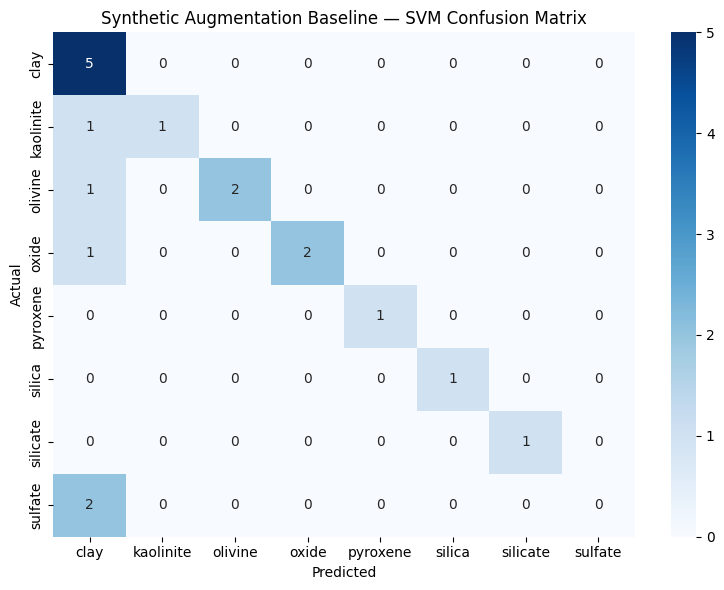

In [15]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=le.classes_,
    yticklabels=le.classes_
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Synthetic Augmentation Baseline — SVM Confusion Matrix")
plt.tight_layout()
plt.show()

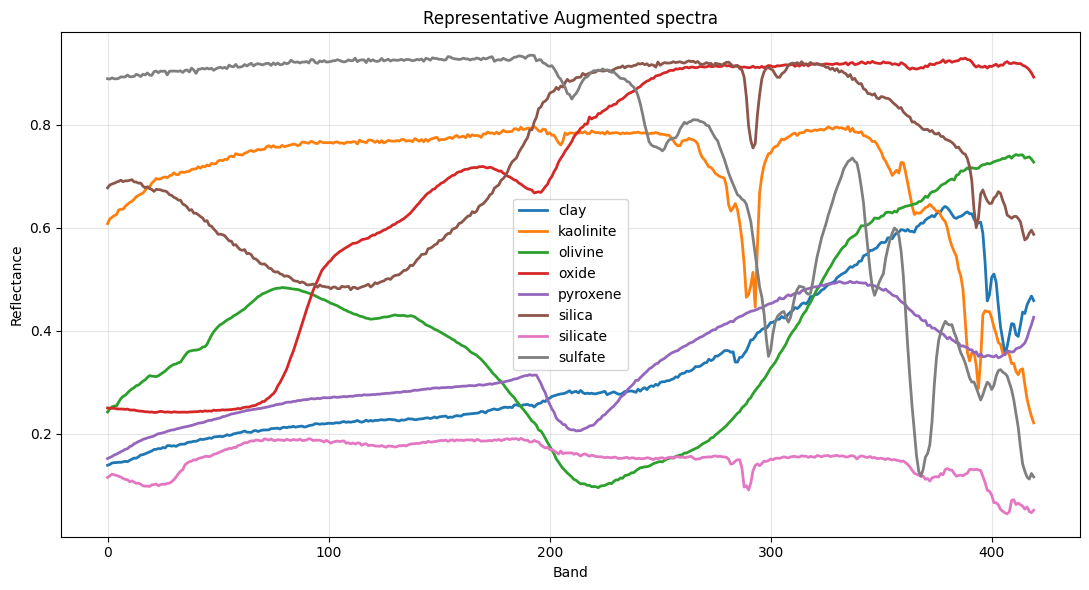

In [16]:
plt.figure(figsize=(11, 6))

for cls in np.unique(y):
    idx = np.where(y == cls)[0][0]
    plt.plot(np.arange(X.shape[1]), X[idx], label=cls, linewidth=2)

plt.xlabel("Band")
plt.ylabel("Reflectance")
plt.title("Representative Augmented spectra")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

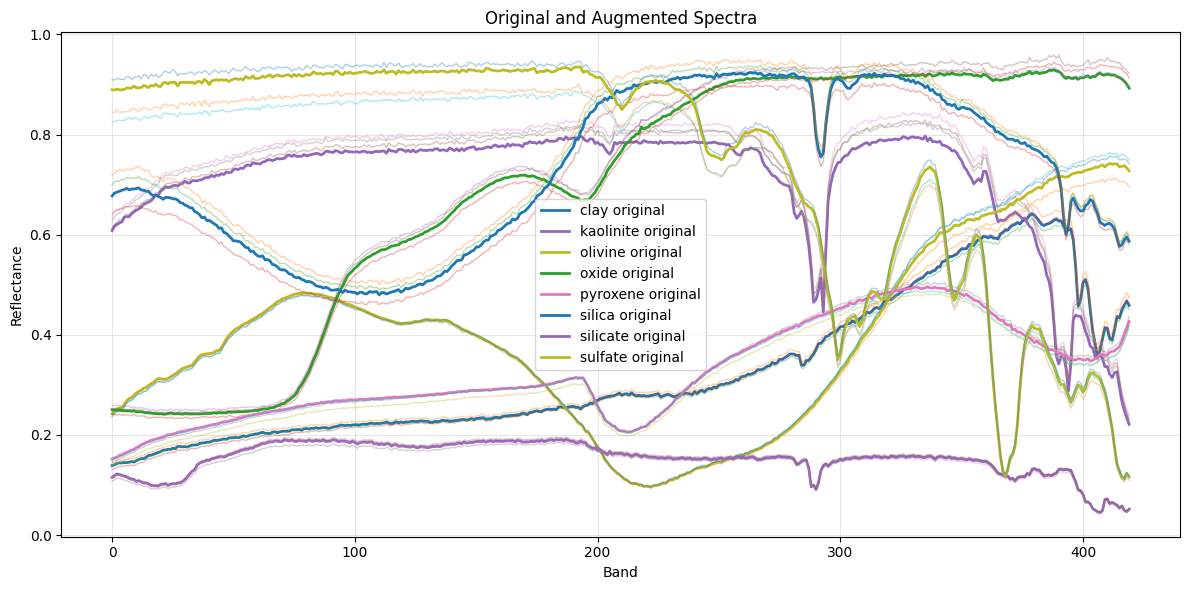

In [17]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

# pick a few representative classes
classes_to_show = ["clay", "kaolinite", "olivine", "oxide", "pyroxene", "silica", "silicate", "sulfate"]

plt.figure(figsize=(12, 6))

for cls in classes_to_show:
    idx = np.where(y == cls)[0][0]   # original spectrum index
    orig = X[idx]

    # plot original
    plt.plot(np.arange(orig.shape[0]), orig, linewidth=2, label=f"{cls} original")

    # plot 3 augmented versions
    for _ in range(3):
        aug = augment_spectrum(orig, rng)
        plt.plot(np.arange(aug.shape[0]), aug, alpha=0.35, linewidth=1)

plt.xlabel("Band")
plt.ylabel("Reflectance")
plt.title("Original and Augmented Spectra")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

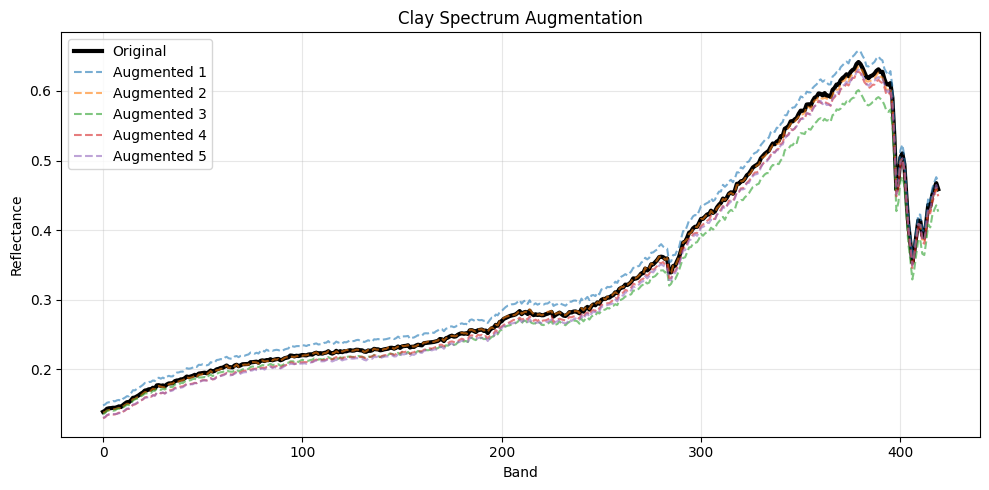

In [18]:
import matplotlib.pyplot as plt
import numpy as np

cls = "clay"

idx = np.where(y == cls)[0][0]
orig = X[idx]

plt.figure(figsize=(10,5))

# Original spectrum
plt.plot(orig,
         linewidth=3,
         color='black',
         label='Original')

# Augmented versions
for i in range(5):
    aug = augment_spectrum(orig, rng)
    plt.plot(aug,
             alpha=0.6,
             linewidth=1.5,
             linestyle='--',
             label=f'Augmented {i+1}')

plt.title(f"{cls.capitalize()} Spectrum Augmentation")
plt.xlabel("Band")
plt.ylabel("Reflectance")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

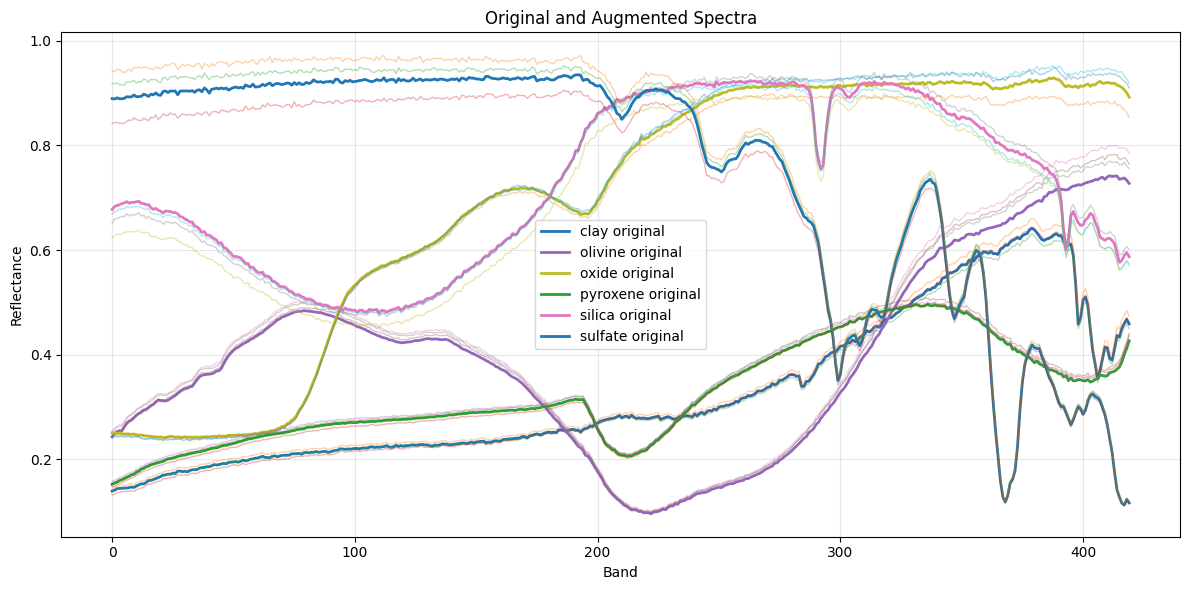

In [19]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

# pick a few representative classes
classes_to_show = ["clay", "olivine", "oxide", "pyroxene", "silica", "sulfate"]

plt.figure(figsize=(12, 6))

for cls in classes_to_show:
    idx = np.where(y == cls)[0][0]   # original spectrum index
    orig = X[idx]

    # plot original
    plt.plot(np.arange(orig.shape[0]), orig, linewidth=2, label=f"{cls} original")

    # plot 3 augmented versions
    for _ in range(3):
        aug = augment_spectrum(orig, rng)
        plt.plot(np.arange(aug.shape[0]), aug, alpha=0.35, linewidth=1)

plt.xlabel("Band")
plt.ylabel("Reflectance")
plt.title("Original and Augmented Spectra")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

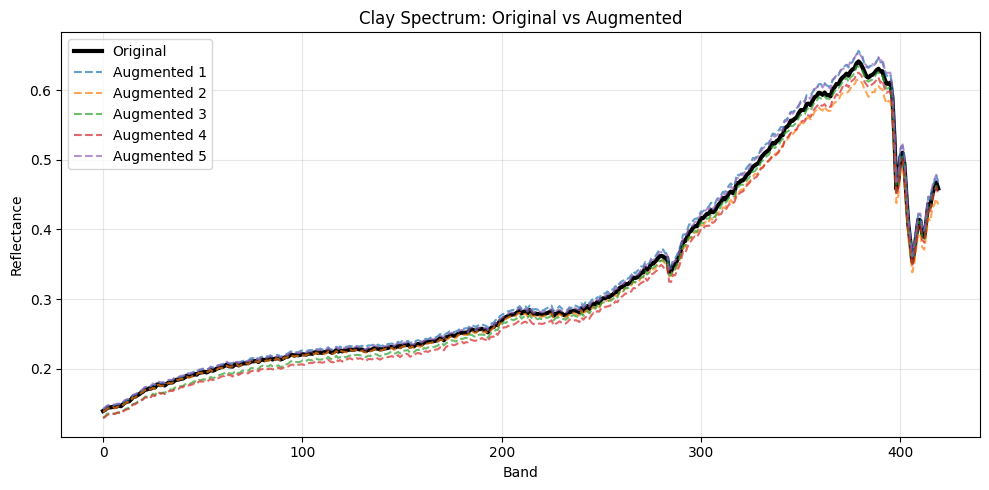

In [20]:
import numpy as np
import matplotlib.pyplot as plt

# pick one class to show
cls = "clay"   # change to: kaolinite, olivine, oxide, pyroxene, silica, silicate, sulfate

# find one example spectrum of that class
idx = np.where(y == cls)[0][0]
orig = X[idx]

plt.figure(figsize=(10, 5))

# original spectrum
plt.plot(orig, linewidth=3, color="black", label="Original")

# a few augmented versions
for i in range(5):
    aug = augment_spectrum(orig, rng)
    plt.plot(aug, linewidth=1.5, alpha=0.7, linestyle="--", label=f"Augmented {i+1}")

plt.title(f"{cls.capitalize()} Spectrum: Original vs Augmented")
plt.xlabel("Band")
plt.ylabel("Reflectance")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

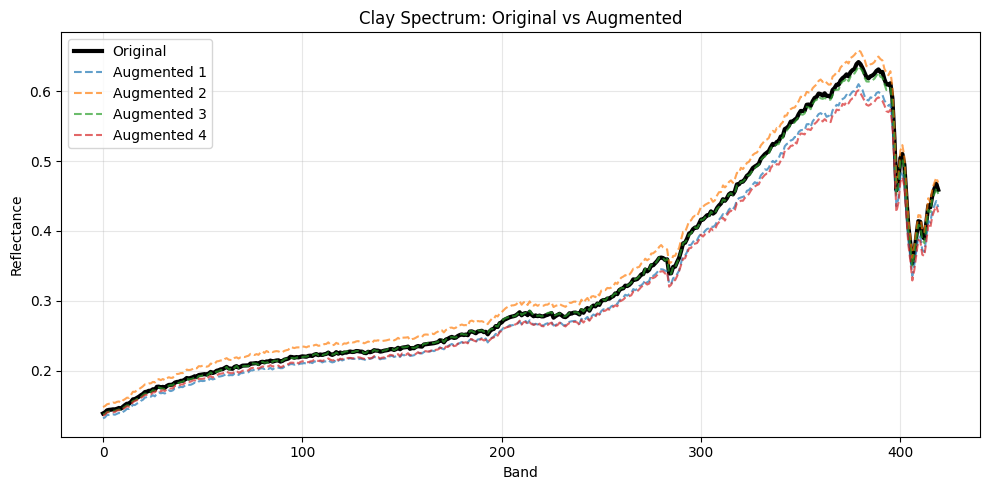

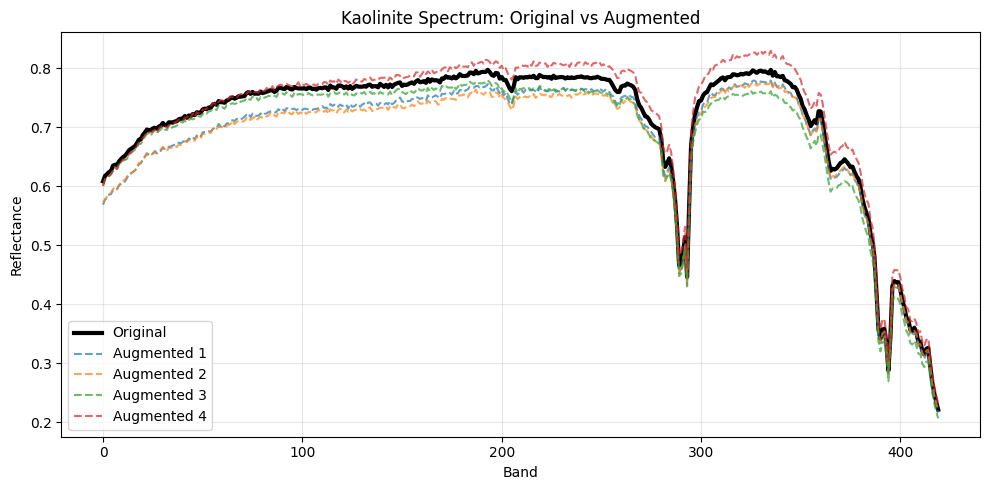

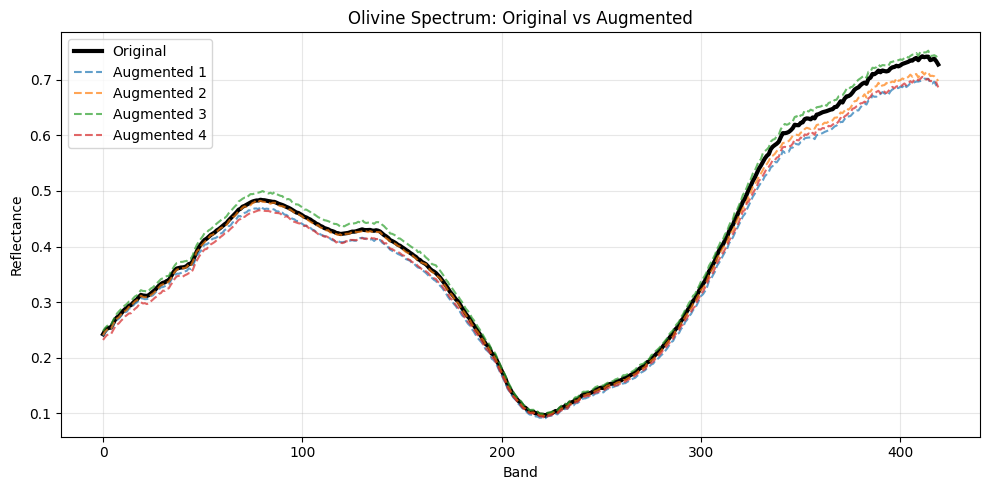

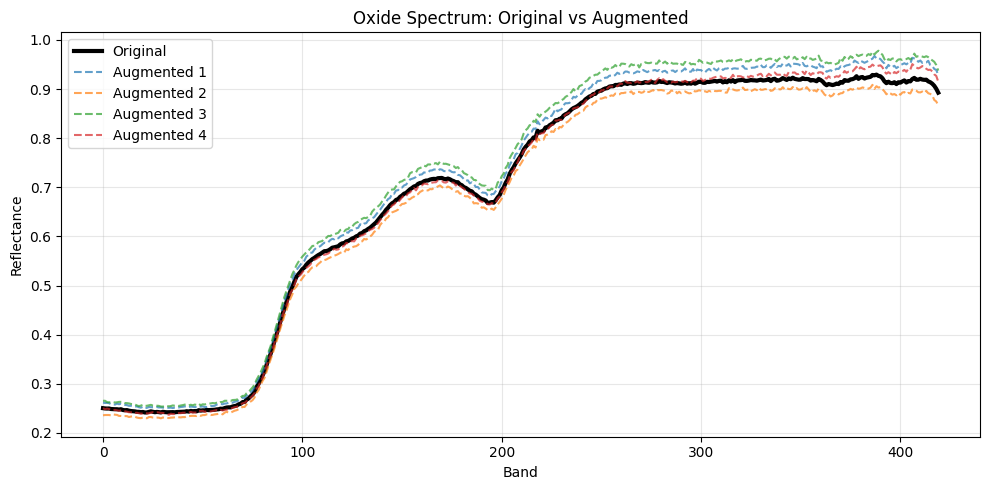

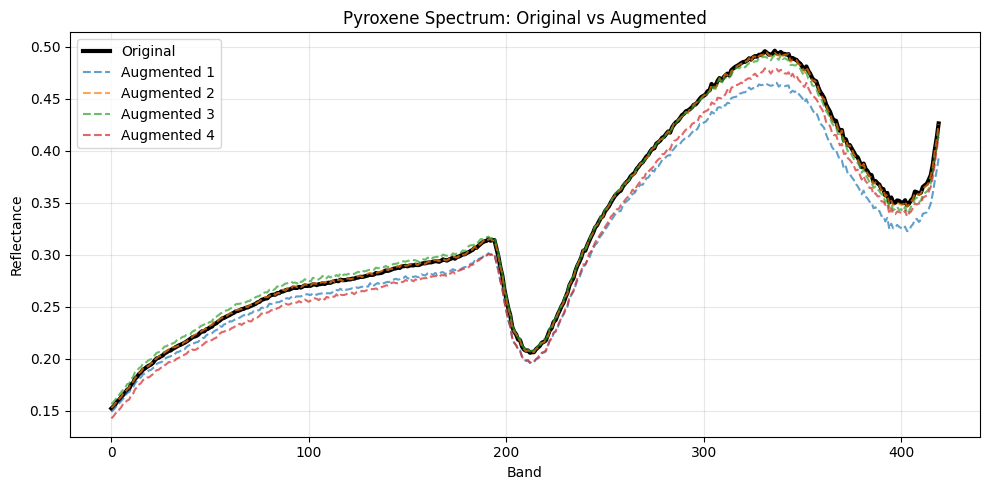

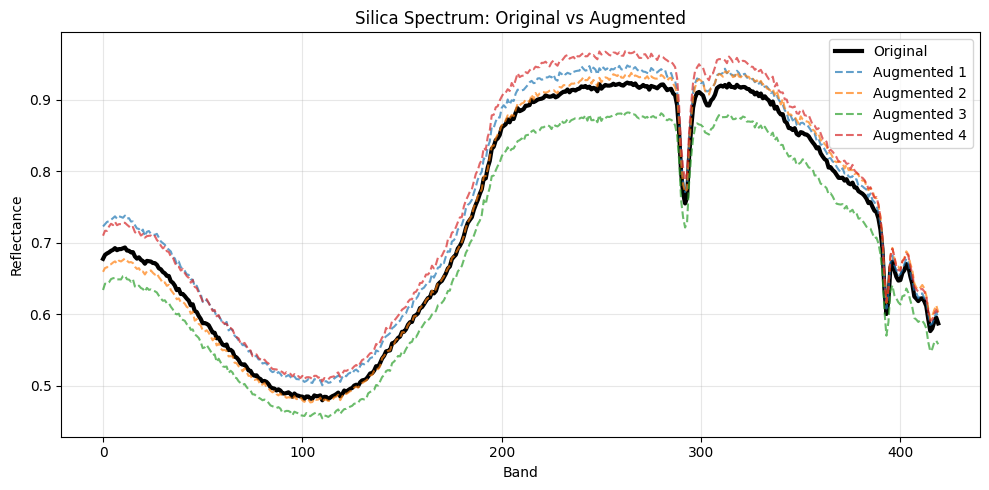

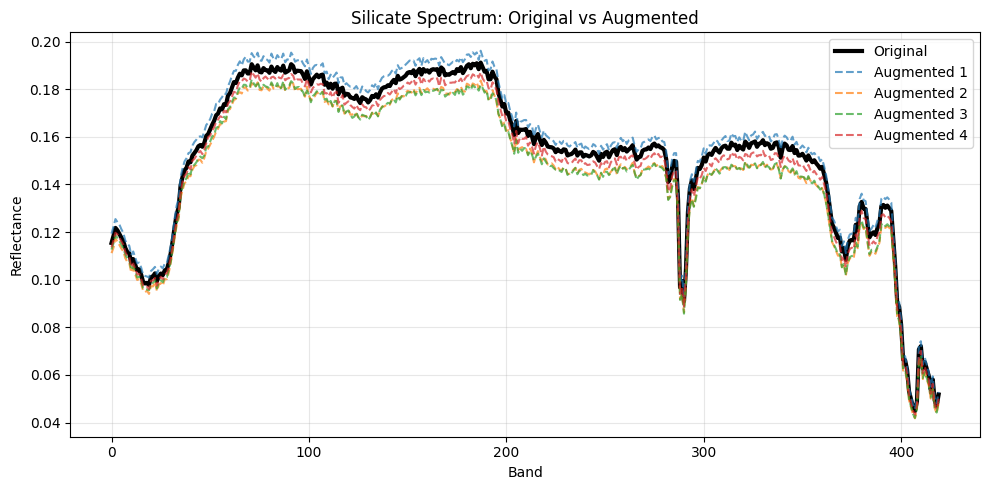

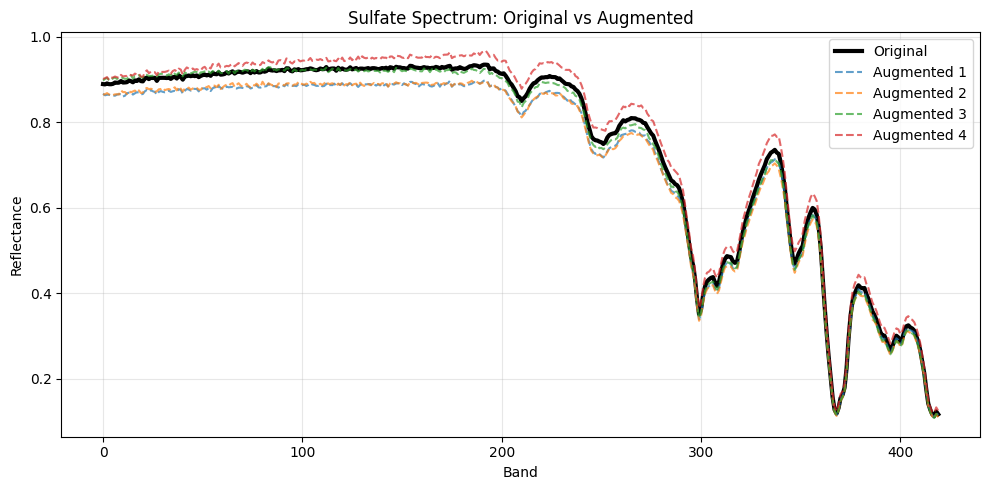

In [21]:
classes_to_show = ["clay", "kaolinite", "olivine", "oxide", "pyroxene", "silica", "silicate", "sulfate"]

for cls in classes_to_show:
    if cls not in y:
        continue

    idx = np.where(y == cls)[0][0]
    orig = X[idx]

    plt.figure(figsize=(10, 5))
    plt.plot(orig, linewidth=3, color="black", label="Original")

    for i in range(4):
        aug = augment_spectrum(orig, rng)
        plt.plot(aug, linewidth=1.5, alpha=0.7, linestyle="--", label=f"Augmented {i+1}")

    plt.title(f"{cls.capitalize()} Spectrum: Original vs Augmented")
    plt.xlabel("Band")
    plt.ylabel("Reflectance")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [22]:
rf_model = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=grid.best_params_["pca__n_components"], random_state=42)),
    ("rf", RandomForestClassifier(
        n_estimators=300,
        max_depth=25,
        class_weight="balanced",
        random_state=42
    ))
])

rf_model.fit(X_aug, y_aug)
y_pred_rf = rf_model.predict(X_test)

print("RF accuracy:", accuracy_score(y_test, y_pred_rf))
print("RF macro-F1:", f1_score(y_test, y_pred_rf, average="macro"))
print()
print(classification_report(y_test, y_pred_rf, target_names=le.classes_))

RF accuracy: 0.7222222222222222
RF macro-F1: 0.6404761904761904

              precision    recall  f1-score   support

        clay       0.60      0.60      0.60         5
   kaolinite       1.00      0.50      0.67         2
     olivine       1.00      1.00      1.00         3
       oxide       0.75      1.00      0.86         3
    pyroxene       0.00      0.00      0.00         1
      silica       0.50      1.00      0.67         1
    silicate       0.50      1.00      0.67         1
     sulfate       1.00      0.50      0.67         2

    accuracy                           0.72        18
   macro avg       0.67      0.70      0.64        18
weighted avg       0.74      0.72      0.70        18



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [23]:
joblib.dump(best_model, "synthetic_svm_pipeline.joblib")
joblib.dump(le, "synthetic_label_encoder.joblib")

print("Saved model and encoder.")

Saved model and encoder.


In [24]:
from spectral import envi
import numpy as np
import joblib
import matplotlib.pyplot as plt

# change these paths to your actual ENVI export
gale_hdr = "/kaggle/input/datasets/urayushmishra/galeroiiii/GaleROIIII.hdr"
gale_img = "/kaggle/input/datasets/urayushmishra/galeroiiii/GaleROIIII"

img = envi.open(gale_hdr, gale_img)
cube = np.asarray(img.load(), dtype=np.float32)

print("Cube shape:", cube.shape)   # expected: (rows, cols, 420)

Cube shape: (623, 570, 489)


In [25]:
rows, cols, bands = cube.shape
X_gale = cube.reshape(-1, bands)

# keep only non-background pixels
valid_mask = np.any(X_gale != 0, axis=1)
X_gale_valid = X_gale[valid_mask]

print("Valid pixels:", X_gale_valid.shape)

Valid pixels: (355110, 489)


In [26]:
from scipy.interpolate import interp1d
import numpy as np

def resample_spectrum(spec, old_wl, new_wl):
    f = interp1d(old_wl, spec, kind='linear', bounds_error=False, fill_value="extrapolate")
    return f(new_wl)

In [27]:
# Gale wavelengths (489)
old_gale_wl = np.array(img.bands.centers)

print("Gale wavelengths:", len(old_gale_wl))

Gale wavelengths: 489


In [28]:
from spectral import envi

lib = envi.open(
    "/kaggle/input/datasets/urayushmishra/gale-crater/min_set3.hdr",
    "/kaggle/input/datasets/urayushmishra/gale-crater/min_set3"
)

target_wl = np.array(lib.bands.centers)

print("Target wavelengths:", len(target_wl))

Target wavelengths: 420


In [29]:
# cube shape = (rows, cols, 489)
X_gale = cube.reshape(-1, cube.shape[2])

# old_gale_wl should be length 489
# target_wl should be length 420 (same as your synthetic training model)

X_gale_resampled = np.array([
    resample_spectrum(s, old_gale_wl, target_wl)
    for s in X_gale_valid
])

print(X_gale_resampled.shape)  # should be (num_pixels, 420)

(355110, 420)


In [30]:
# X_gale_resampled = X_gale_resampled / (
#     np.max(X_gale_resampled, axis=1, keepdims=True) + 1e-8
# )

In [31]:
model = joblib.load("/kaggle/working/synthetic_svm_pipeline.joblib")

map_pred_filteredy_gale_pred = model.predict(X_gale_resampled)

print("Predicted labels shape:", y_gale_pred.shape)
print("Unique predictions:", np.unique(y_gale_pred))

NameError: name 'y_gale_pred' is not defined

In [ ]:
full_pred = np.full(X_gale.shape[0], -1, dtype=int)
full_pred[valid_mask] = y_gale_pred

pred_map = full_pred.reshape(rows, cols)
print("Pred map shape:", pred_map.shape)

In [ ]:
le = joblib.load("/kaggle/working/synthetic_label_encoder.joblib")
class_names = le.classes_

plt.figure(figsize=(8, 8))
plt.imshow(pred_map, cmap="tab20")
plt.colorbar()
plt.title("Synthetic Baseline Prediction on Gale Crater")
plt.axis("off")
plt.show()

In [ ]:
unique_ids = np.unique(y_gale_pred)
print("Predicted class IDs:", unique_ids)

plt.figure(figsize=(8, 8))
im = plt.imshow(pred_map, cmap="tab20")
cbar = plt.colorbar(im, ticks=range(len(class_names)))
cbar.ax.set_yticklabels(class_names)
plt.title("Gale Crater Mineral Prediction")
plt.axis("off")
plt.show()

In [ ]:
unique, counts = np.unique(y_gale_pred, return_counts=True)

for u, c in zip(unique, counts):
    print(f"{u}: {c}")

In [ ]:
total = len(y_gale_pred)

for u, c in zip(unique, counts):
    print(f"{u}: {c} pixels ({100*c/total:.2f}%)")

In [ ]:
print(le.classes_)

In [ ]:
for i, cls in enumerate(le.classes_):
    print(i, ":", cls)

In [ ]:
from scipy.ndimage import median_filter

map_pred_filtered = median_filter(pred_map, size=3)

In [ ]:
plt.figure(figsize=(8,8))
plt.imshow(map_pred_filtered, cmap='tab20')
plt.title("Filtered Gale Crater Mineral Map")
plt.colorbar()
plt.show()